# Comparación de modelos — Ejercicio 2

El objetivo de este notebook es comparar todos los modelos entrenados para el Ejercicio 2 y seleccionar el mejor modelo para su posterior reentrenamiento y exportación a la aplicación web.

La comparación se realiza sobre el horizonte predictivo principal de la propuesta:

`target_stress_t24`

La métrica principal de selección es el **RMSE en test**, ya que el problema principal se formula como una tarea de regresión sobre el nivel de estrés urbano.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / ".git").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()
COMPARISON_PATH = PROJECT_ROOT / "outputs/ejercicio2/comparison/model_comparison.csv"

if not COMPARISON_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo de comparación: {COMPARISON_PATH}")

df = pd.read_csv(COMPARISON_PATH)
df

,model,target,rmse_test,mae_test,r2_test,accuracy_test,f1_test,report_file
0,baseline_persistence_current_stress,target_stress_t24,1.096200,0.617200,0.533500,0.981600,0.412100,outputs\ejercicio2\reports\baseline\baseline_r...
1,baseline_zone_hour_weekend_mean,target_stress_t24,2.192300,1.939500,-0.865900,0.953300,0.229800,outputs\ejercicio2\reports\baseline\baseline_r...
2,baseline_global_mean,target_stress_t24,2.460600,2.156300,-1.350700,0.984300,0.000000,outputs\ejercicio2\reports\baseline\baseline_r...
3,xgboost,target_stress_t24,0.828999,0.517242,0.733192,0.973146,0.426375,outputs\ejercicio2\reports\boosting\xgboost_re...
4,GBTRegressor_spark,target_stress_t24,0.856588,0.534785,0.715136,NaN,NaN,outputs\ejercicio2\reports\gbt\gbt_stress_spar...
5,EmbeddingMLPRegressor_torch,target_stress_t24,0.867213,0.581780,0.708025,NaN,NaN,outputs\ejercicio2\reports\neural_network\neur...
6,RandomForestRegressor_spark,target_stress_t24,0.857497,0.533631,0.714531,NaN,NaN,outputs\ejercicio2\reports\random_forest\rando...


## Limpieza de resultados

El archivo de comparación contiene las métricas exportadas por cada modelo. Para la comparación final se filtran únicamente los modelos con valores válidos de RMSE y el target principal del ejercicio (`target_stress_t24`).

In [2]:
TARGET = "target_stress_t24"

df_clean = df.copy()
df_clean = df_clean[df_clean["target"] == TARGET]
df_clean = df_clean.dropna(subset=["rmse_test"])

df_clean = df_clean.sort_values("rmse_test", ascending=True).reset_index(drop=True)

df_clean

,model,target,rmse_test,mae_test,r2_test,accuracy_test,f1_test,report_file
0,xgboost,target_stress_t24,0.828999,0.517242,0.733192,0.973146,0.426375,outputs\ejercicio2\reports\boosting\xgboost_re...
1,GBTRegressor_spark,target_stress_t24,0.856588,0.534785,0.715136,NaN,NaN,outputs\ejercicio2\reports\gbt\gbt_stress_spar...
2,RandomForestRegressor_spark,target_stress_t24,0.857497,0.533631,0.714531,NaN,NaN,outputs\ejercicio2\reports\random_forest\rando...
3,EmbeddingMLPRegressor_torch,target_stress_t24,0.867213,0.581780,0.708025,NaN,NaN,outputs\ejercicio2\reports\neural_network\neur...
4,baseline_persistence_current_stress,target_stress_t24,1.096200,0.617200,0.533500,0.981600,0.412100,outputs\ejercicio2\reports\baseline\baseline_r...
5,baseline_zone_hour_weekend_mean,target_stress_t24,2.192300,1.939500,-0.865900,0.953300,0.229800,outputs\ejercicio2\reports\baseline\baseline_r...
6,baseline_global_mean,target_stress_t24,2.460600,2.156300,-1.350700,0.984300,0.000000,outputs\ejercicio2\reports\baseline\baseline_r...


## Tabla comparativa

La siguiente tabla resume el rendimiento de los modelos en el conjunto de test. Se muestran las métricas principales de regresión y, cuando están disponibles, las métricas de clasificación asociadas a la detección de situaciones de estrés.

In [3]:
cols = [
    "model",
    "target",
    "rmse_test",
    "mae_test",
    "r2_test",
    "accuracy_test",
    "f1_test",
]

table = df_clean[cols].copy()

table["rmse_test"] = table["rmse_test"].round(4)
table["mae_test"] = table["mae_test"].round(4)
table["r2_test"] = table["r2_test"].round(4)
table["accuracy_test"] = table["accuracy_test"].round(4)
table["f1_test"] = table["f1_test"].round(4)

table

,model,target,rmse_test,mae_test,r2_test,accuracy_test,f1_test
0,xgboost,target_stress_t24,0.8290,0.5172,0.7332,0.9731,0.4264
1,GBTRegressor_spark,target_stress_t24,0.8566,0.5348,0.7151,NaN,NaN
2,RandomForestRegressor_spark,target_stress_t24,0.8575,0.5336,0.7145,NaN,NaN
3,EmbeddingMLPRegressor_torch,target_stress_t24,0.8672,0.5818,0.7080,NaN,NaN
4,baseline_persistence_current_stress,target_stress_t24,1.0962,0.6172,0.5335,0.9816,0.4121
5,baseline_zone_hour_weekend_mean,target_stress_t24,2.1923,1.9395,-0.8659,0.9533,0.2298
6,baseline_global_mean,target_stress_t24,2.4606,2.1563,-1.3507,0.9843,0.0000


## Comparación visual del RMSE

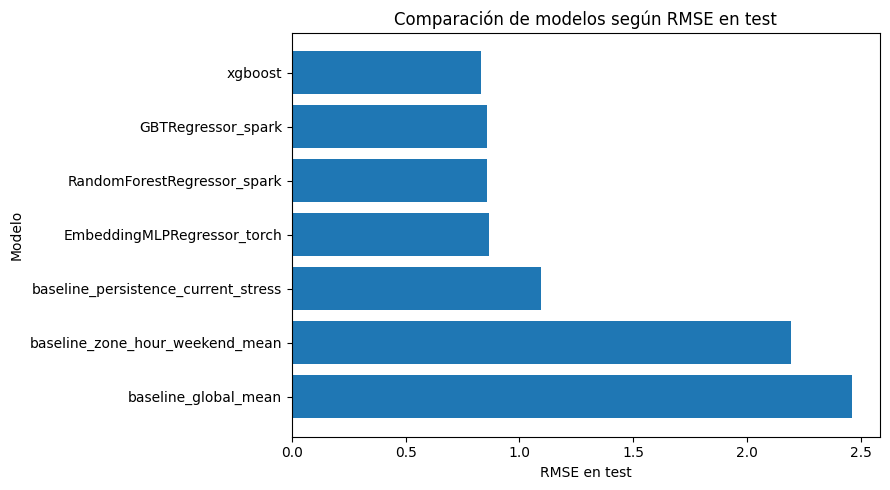

In [4]:
plot_df = df_clean.sort_values("rmse_test", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["rmse_test"])
plt.xlabel("RMSE en test")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según RMSE en test")
plt.tight_layout()
plt.show()

El gráfico muestra que los modelos avanzados reducen el error respecto a los baselines. Entre ellos, el modelo con menor RMSE es el candidato más adecuado para el despliegue, ya que presenta el mejor rendimiento sobre datos no vistos.

## Comparación de MAE y R²

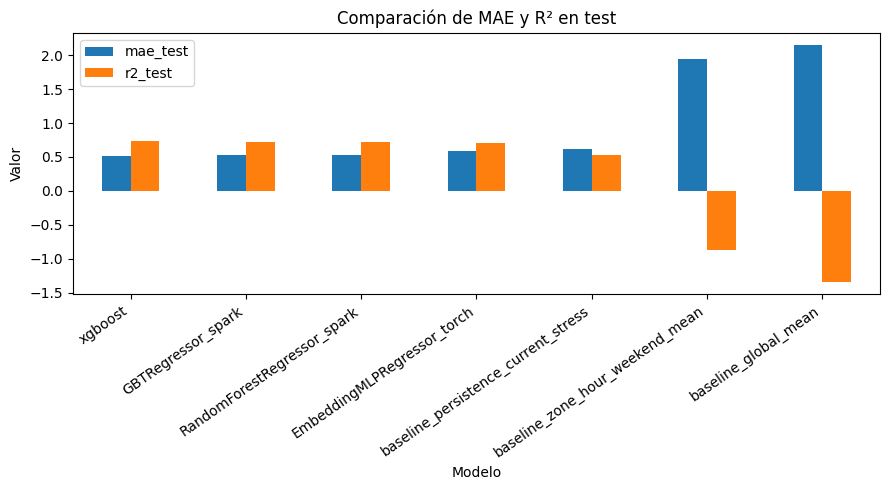

In [5]:
metric_df = df_clean[["model", "mae_test", "r2_test"]].copy()
metric_df = metric_df.set_index("model")

ax = metric_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Comparación de MAE y R² en test")
ax.set_ylabel("Valor")
ax.set_xlabel("Modelo")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Además del RMSE, el MAE permite interpretar el error medio absoluto, mientras que el R² indica qué proporción de la variabilidad del estrés es explicada por el modelo. En conjunto, estas métricas permiten valorar no solo el error, sino también la capacidad explicativa del modelo.

## Selección automática del mejor modelo

In [6]:
best_model = df_clean.sort_values("rmse_test", ascending=True).iloc[0]

best_model

model                                                      xgboost
target                                           target_stress_t24
rmse_test                                                 0.828999
mae_test                                                  0.517242
r2_test                                                   0.733192
accuracy_test                                             0.973146
f1_test                                                   0.426375
report_file      outputs\ejercicio2\reports\boosting\xgboost_re...
Name: 0, dtype: object

In [7]:
print("Mejor modelo seleccionado:")
print(f"Modelo: {best_model['model']}")
print(f"Target: {best_model['target']}")
print(f"RMSE test: {best_model['rmse_test']:.4f}")
print(f"MAE test: {best_model['mae_test']:.4f}")
print(f"R² test: {best_model['r2_test']:.4f}")

if pd.notna(best_model.get("accuracy_test")):
    print(f"Accuracy test: {best_model['accuracy_test']:.4f}")

if pd.notna(best_model.get("f1_test")):
    print(f"F1 test: {best_model['f1_test']:.4f}")

Mejor modelo seleccionado:
Modelo: xgboost
Target: target_stress_t24
RMSE test: 0.8290
MAE test: 0.5172
R² test: 0.7332
Accuracy test: 0.9731
F1 test: 0.4264


El modelo seleccionado automáticamente es el que obtiene el menor RMSE en el conjunto de test. Esta selección se integra posteriormente en el pipeline de exportación, que reentrena el modelo ganador utilizando todos los datos disponibles antes de generar el artefacto final para la web.

## Conclusiones

La comparación muestra que los modelos avanzados mejoran claramente el rendimiento de los baselines, lo que confirma que el problema requiere modelos capaces de capturar relaciones no lineales entre demanda, precio, variabilidad y contexto temporal.

El modelo seleccionado presenta el menor error en test, por lo que se utiliza como modelo final para el despliegue. Este enfoque permite mantener un proceso reproducible: si en el futuro se incorporan nuevos datos o nuevos modelos, el sistema puede volver a comparar los resultados y seleccionar automáticamente la mejor alternativa.

<!-- ## Conclusiones

La comparación muestra que los modelos avanzados mejoran claramente el rendimiento de los baselines, lo que confirma que el problema requiere modelos capaces de capturar relaciones no lineales entre demanda, precio, variabilidad y contexto temporal.

El modelo seleccionado presenta el menor error en test, por lo que se utiliza como modelo final para el despliegue. Este enfoque permite mantener un proceso reproducible: si en el futuro se incorporan nuevos datos o nuevos modelos, el sistema puede volver a comparar los resultados y seleccionar automáticamente la mejor alternativa. -->